# WildRF preliminary EDA — Deepfake Detection Web App

**Dataset:** WildRF (Cavia et al., *Real-Time Deepfake Detection in the Real-World*). This notebook analyzes **images only**; it cannot establish video or audio suitability. CPU only, fixed seed, no deep-model training. Target runtime is under about 30 minutes on free Colab, but download and face detection depend on service speed. Set `SAMPLE_PER_GROUP` lower for face detection and contact sheets if needed; inventory and duplicate checks still cover all files.

**Project questions:** NFR-4 (social-media compression), FR-8 (face crop), NFR-17 (false positives on authentic compressed media), DR-3/6/12 (non-commercial use, consent/privacy, no third-party sharing). Do not upload dataset images or contact sheets to a public repository. The `results.zip` includes contact sheets of potentially identifiable people; share it only with authorized team members.

**Sources:** [authors' README](https://github.com/barcavia/RealTime-DeepfakeDetection-in-the-RealWorld#datasets), [repository LICENSE](https://github.com/barcavia/RealTime-DeepfakeDetection-in-the-RealWorld/blob/main/LICENSE), [project page](https://vision.huji.ac.il/ladeda/), [paper](https://arxiv.org/abs/2406.09398). The README links [WildRF.zip on Google Drive](https://drive.google.com/file/d/1A0xoL44Yg68ixd-FuIJn2VC4vdZ6M2gn/view?usp=sharing). The repository license is a **Software Research License** permitting research/teaching use of its defined technology and excluding commercial use; the README and license do **not clearly state separate rights or consent terms for the dataset images**. The project-page footer's CC BY-SA notice applies to the website, not necessarily the images. Obtain a dataset-use clarification before deployment, redistribution, or third-party sharing. This is a research observation, not legal advice.

The README describes `WildRF/train/{0_real,1_fake}`, `WildRF/val/{0_real,1_fake}`, and `WildRF/test/{reddit,twitter,facebook}/{0_real,1_fake}`. It says images were manually collected using keywords/hashtags and proposes training on one platform (e.g. Reddit) and testing on unseen platforms (e.g. Twitter/Facebook). Train/val folders themselves do not encode platform provenance. The following claims are **unverified until this notebook runs**: about 5,300 images; Reddit 2,150/2,150, Twitter 340/340, Facebook 160/160 (possibly test only); class balance; removal of JPEG-vs-PNG bias. Metadata checks can test format associations, but cannot prove how a dataset was curated.

## 1. Setup and run settings

Use a CPU runtime. `SAMPLE_PER_GROUP` controls slow face analysis per split × platform × label; set `None` to process all images. Contact sheets use up to 30 per label per platform. All scans use local files and write incremental outputs under `/content/results/`.

In [ ]:
%pip -q install gdown imagehash scikit-learn pandas matplotlib tqdm pillow
# facenet-pytorch may pin an incompatible torchvision on Colab; use existing torch.
%pip -q install --no-deps facenet-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 23.3 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import collections, hashlib, json, math, random, shutil, subprocess, sys, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, UnidentifiedImageError
from tqdm.auto import tqdm
import imagehash

SEED = 20260930
SAMPLE_PER_GROUP = 40  # face detection; None means all
NEAR_HASH_DISTANCE = 5
CONTACT_PER_LABEL_PLATFORM = 30
ROOT = Path('/content/WildRF')
RESULTS = Path('/content/results')
FIGURES = RESULTS / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
random.seed(SEED); np.random.seed(SEED)
summary = {'dataset': 'WildRF', 'seed': SEED, 'settings': {
    'sample_per_group': SAMPLE_PER_GROUP, 'near_hash_distance': NEAR_HASH_DISTANCE,
    'contact_per_label_platform': CONTACT_PER_LABEL_PLATFORM}}

def report(section, data):
    def convert(value):
        if isinstance(value, np.integer): return int(value)
        if isinstance(value, np.floating): return float(value)
        if isinstance(value, np.bool_): return bool(value)
        raise TypeError(f'Cannot serialize {type(value)}')
    summary[section] = json.loads(json.dumps(data, default=convert))
    (RESULTS / 'summary.json').write_text(json.dumps(summary, indent=2))
    print(json.dumps({section: summary[section]}, indent=2))

report('status', {'stage': 'setup_complete', 'dataset_downloaded': False})

{
  "status": {
    "stage": "setup_complete",
    "dataset_downloaded": false
  }
}


## 2. Download, with a user-provided Drive fallback

The primary cell uses the exact Drive link in the authors' README. If Google Drive rate limits it, run the clearly labelled fallback cell after placing the zip in your own Drive. Extraction checks for path traversal and never overwrites arbitrary locations. The unzipped dataset stays only in Colab's temporary session.

In [ ]:
DRIVE_URL = 'https://drive.google.com/file/d/1A0xoL44Yg68ixd-FuIJn2VC4vdZ6M2gn/view?usp=sharing'
ZIP_PATH = Path('/content/WildRF.zip')

def extract_wildrf(zip_path):
    ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as archive:
        members = archive.infolist()
        for item in members:
            target = (ROOT / item.filename).resolve()
            if not target.is_relative_to(ROOT.resolve()):
                raise ValueError(f'Unsafe zip member: {item.filename}')
        archive.extractall(ROOT)
    candidates = [p for p in ROOT.rglob('train') if p.is_dir() and (p.parent / 'test').is_dir()]
    if len(candidates) != 1:
        raise RuntimeError(f'Expected one dataset root, found: {[str(p.parent) for p in candidates]}')
    return candidates[0].parent

DATA_ROOT = None
try:
    import gdown
    gdown.download(DRIVE_URL, str(ZIP_PATH), quiet=False, fuzzy=True)
    if not ZIP_PATH.exists() or not zipfile.is_zipfile(ZIP_PATH):
        raise RuntimeError('No valid zip downloaded')
    DATA_ROOT = extract_wildrf(ZIP_PATH)
    report('download', {'method': 'gdown', 'dataset_root': str(DATA_ROOT), 'zip_bytes': ZIP_PATH.stat().st_size})
except Exception as exc:
    print('PRIMARY DOWNLOAD FAILED:', type(exc).__name__, str(exc))
    print("Run the FALLBACK cell below after placing the authors' zip in your Google Drive.")

Downloading...
From (original): https://drive.google.com/uc?id=1A0xoL44Yg68ixd-FuIJn2VC4vdZ6M2gn
From (redirected): https://drive.google.com/uc?id=1A0xoL44Yg68ixd-FuIJn2VC4vdZ6M2gn&confirm=t&uuid=6804cc16-964a-4203-88ce-7606085f00e2
To: /content/WildRF.zip
100%|██████████| 6.40G/6.40G [01:19<00:00, 80.3MB/s]


{
  "download": {
    "method": "gdown",
    "dataset_root": "/content/WildRF/WildRF",
    "zip_bytes": 6403695558
  }
}


### FALLBACK: zip already placed in your Google Drive

Run this only if the primary download failed. Set `MY_DRIVE_ZIP` to the path in your mounted Drive. No login bypass or substitute data is attempted.

In [ ]:
if DATA_ROOT is None:
    from google.colab import drive
    drive.mount('/content/drive')
    MY_DRIVE_ZIP = Path('/content/drive/MyDrive/WildRF.zip')  # EDIT THIS PATH
    if not MY_DRIVE_ZIP.is_file():
        raise FileNotFoundError(f"Place the authors' zip at {MY_DRIVE_ZIP} or edit MY_DRIVE_ZIP")
    DATA_ROOT = extract_wildrf(MY_DRIVE_ZIP)
    report('download', {'method': 'user_drive_zip', 'dataset_root': str(DATA_ROOT),
                        'zip_bytes': MY_DRIVE_ZIP.stat().st_size})
else:
    print('Primary download succeeded; fallback not needed.')

Primary download succeeded; fallback not needed.


## 3. Verify layout and inventory

Count every file in the documented leaf folders, report missing/extra folders, and attempt full image decoding. An extension is not the actual image format. Unexpected files are retained in the inventory for review but excluded from label-based analyses. `metadata.csv` is saved immediately.

In [ ]:
assert DATA_ROOT is not None and DATA_ROOT.is_dir(), 'Download or fallback must succeed first.'
expected = {f'{s}/{label}' for s in ('train', 'val') for label in ('0_real', '1_fake')}
expected |= {f'test/{platform}/{label}' for platform in ('reddit', 'twitter', 'facebook')
             for label in ('0_real', '1_fake')}
actual_leaf = {str(p.relative_to(DATA_ROOT)).replace('\\', '/') for p in DATA_ROOT.rglob('*')
               if p.is_dir() and any(q.is_file() for q in p.iterdir())}
missing = sorted(p for p in expected if not (DATA_ROOT / p).is_dir())
extra = sorted(actual_leaf - expected)
report('layout', {'expected_leaf_folders': sorted(expected), 'missing': missing, 'extra_file_folders': extra})
if missing:
    print('WARNING: expected folders are missing; downstream comparisons may be incomplete.')

def parse_path(path):
    parts = path.relative_to(DATA_ROOT).parts
    if len(parts) == 3 and parts[0] in ('train', 'val') and parts[1] in ('0_real', '1_fake'):
        return parts[0], 'unspecified', parts[1]
    if len(parts) == 4 and parts[0] == 'test' and parts[1] in ('reddit', 'twitter', 'facebook') and parts[2] in ('0_real', '1_fake'):
        return parts[0], parts[1], parts[2]
    return 'unexpected', 'unexpected', 'unexpected'

# IJG luminance table; only an approximate fit, not a trustworthy encoding provenance.
IJG_LUMA = np.array([16,11,10,16,24,40,51,61,12,12,14,19,26,58,60,55,
 14,13,16,24,40,57,69,56,14,17,22,29,51,87,80,62,18,22,37,56,68,109,103,77,
 24,35,55,64,81,104,113,92,49,64,78,87,103,121,120,101,72,92,95,98,112,100,103,99]).reshape(8,8)
def jpeg_quality_proxy(qtables):
    if not qtables: return np.nan
    table = np.asarray(next(iter(qtables.values())), dtype=float)
    if table.size != 64: return np.nan
    # Fit IJG quantizers; custom/re-encoded tables may invalidate this estimate.
    errors = []
    for q in range(1, 101):
        scale = 5000/q if q < 50 else 200 - 2*q
        model = np.clip(np.floor((IJG_LUMA * scale + 50)/100), 1, 255).ravel()
        errors.append(np.mean(np.abs(model - table)))
    return int(np.argmin(errors) + 1)

rows = []
all_files = sorted(p for p in DATA_ROOT.rglob('*') if p.is_file())
for p in tqdm(all_files, desc='Decode and inventory'):
    split, platform, label = parse_path(p)
    row = {'path': str(p), 'relative_path': str(p.relative_to(DATA_ROOT)).replace('\\','/'),
           'split': split, 'platform': platform, 'label': label, 'extension': p.suffix.lower(),
           'file_bytes': p.stat().st_size, 'readable': False, 'error': ''}
    try:
        with Image.open(p) as im:
            row.update(width=im.width, height=im.height, actual_format=im.format or 'unknown',
                       mode=im.mode, exif_present=bool(im.getexif()),
                       jpeg_quality_proxy=jpeg_quality_proxy(getattr(im, 'quantization', None)) if im.format == 'JPEG' else np.nan)
            im.load()  # catches truncated data
        row['readable'] = True
        row['aspect_ratio'] = row['width'] / row['height'] if row['height'] else np.nan
        row['bytes_per_pixel'] = row['file_bytes'] / (row['width'] * row['height']) if row['width'] * row['height'] else np.nan
    except Exception as exc:
        row['error'] = f'{type(exc).__name__}: {str(exc)[:150]}'
    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv(RESULTS / 'metadata.csv', index=False)
valid = df[df.readable & df.label.isin(['0_real','1_fake'])].copy()
counts = df.groupby(['split','platform','label'], dropna=False).size().rename('files').reset_index()
print(counts.to_string(index=False))
print('Extension vs actual format:')
print(pd.crosstab(df.extension, df.actual_format, dropna=False).to_string())
claims = {'test/reddit/0_real': 2150, 'test/reddit/1_fake': 2150,
          'test/twitter/0_real': 340, 'test/twitter/1_fake': 340,
          'test/facebook/0_real': 160, 'test/facebook/1_fake': 160}
claim_rows = []
for key, claimed in claims.items():
    split, platform, label = key.split('/')
    observed = int(((df.split==split)&(df.platform==platform)&(df.label==label)).sum())
    claim_rows.append({'folder': key, 'claim': claimed, 'observed': observed, 'matches': observed==claimed})
claim_table = pd.DataFrame(claim_rows)
print('Claims (test folders only; ~5,300 total is separately checked):')
print(claim_table.to_string(index=False))
report('inventory', {'all_files': len(df), 'valid_labeled_images': len(valid),
  'test_folder_files': int((df.split=='test').sum()),
  'unreadable_files': int((~df.readable).sum()), 'unexpected_path_files': int((df.split=='unexpected').sum()),
  'counts': counts.to_dict('records'), 'extension_actual_format':
  pd.crosstab(df.extension, df.actual_format, dropna=False).to_dict(),
  'claims_test_folder_comparison': claim_rows,
  'claim_about_5300_all_files_difference': len(df)-5300,
  'claim_about_5300_test_files_difference': int((df.split=='test').sum())-5300,
  'unreadable_paths': df.loc[~df.readable, ['relative_path','error']].to_dict('records')})

{
  "layout": {
    "expected_leaf_folders": [
      "test/facebook/0_real",
      "test/facebook/1_fake",
      "test/reddit/0_real",
      "test/reddit/1_fake",
      "test/twitter/0_real",
      "test/twitter/1_fake",
      "train/0_real",
      "train/1_fake",
      "val/0_real",
      "val/1_fake"
    ],
    "missing": [],
    "extra_file_folders": []
  }
}


Decode and inventory:   0%|          | 0/5613 [00:00<?, ?it/s]

split    platform  label  files
 test    facebook 0_real    160
 test    facebook 1_fake    160
 test      reddit 0_real    750
 test      reddit 1_fake    750
 test     twitter 0_real    341
 test     twitter 1_fake    342
train unspecified 0_real   1356
train unspecified 1_fake   1356
  val unspecified 0_real    199
  val unspecified 1_fake    199
Extension vs actual format:
actual_format  JPEG   PNG  WEBP
extension                      
.jfif           262     0     0
.jpeg           406     0     0
.jpg           3365     0     1
.png              0  1579     0
Claims (test folders only; ~5,300 total is separately checked):
              folder  claim  observed  matches
  test/reddit/0_real   2150       750    False
  test/reddit/1_fake   2150       750    False
 test/twitter/0_real    340       341    False
 test/twitter/1_fake    340       342    False
test/facebook/0_real    160       160     True
test/facebook/1_fake    160       160     True
{
  "inventory": {
    "all_files":

## 4. What the data is; metadata distributions

These are image files, **not tabular predictor features**. We extract width, height, aspect ratio, actual encoding format, file size, bytes per pixel, EXIF presence, and a rough JPEG quality proxy from quantization tables. The proxy assumes standard IJG luminance quantization; custom tables or repeated social-media recompression make it uncertain. Metadata can reveal shortcuts related to compression rather than manipulation. Summaries are by label **and** platform; unspecified train/val provenance stays unspecified.

                   width                             height                             aspect_ratio                      file_bytes                                     bytes_per_pixel                      jpeg_quality_proxy                       
                   count  median      mean       std  count  median      mean       std        count median   mean    std      count    median         mean          std           count median   mean    std              count median    mean     std
platform    label                                                                                                                                                                                                                                      
facebook    0_real   160  1116.0  1169.631   432.062    160  1209.5  1286.900   467.074          160  0.800  0.950  0.307        160  172972.0   213152.375   155635.043             160  0.121  0.143  0.070                160   74.0  75.756   8.502
        

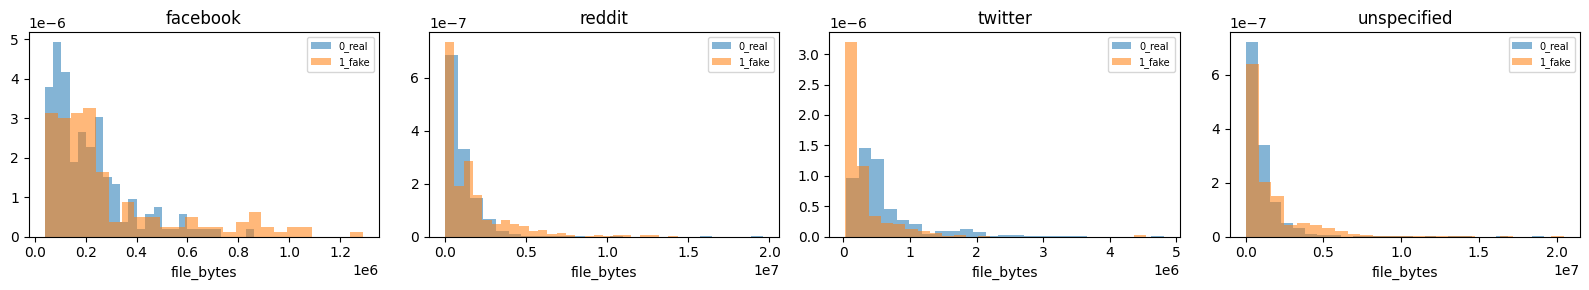

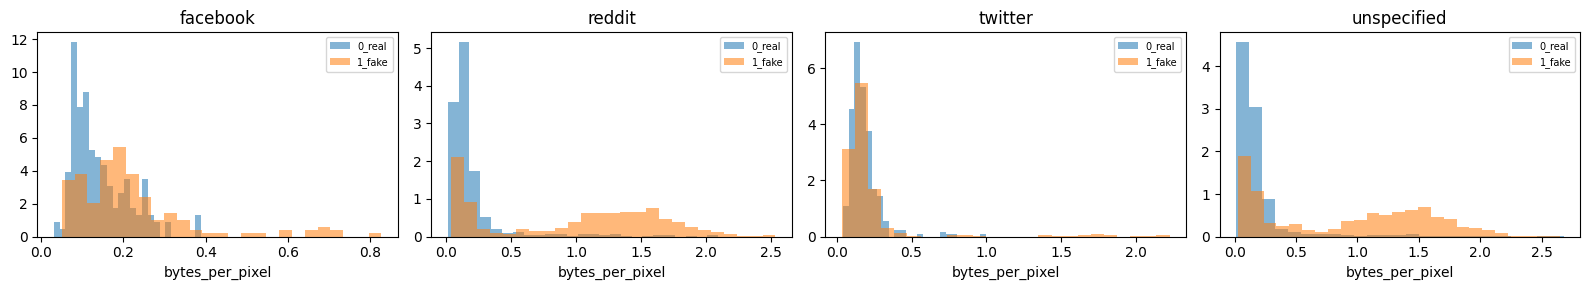

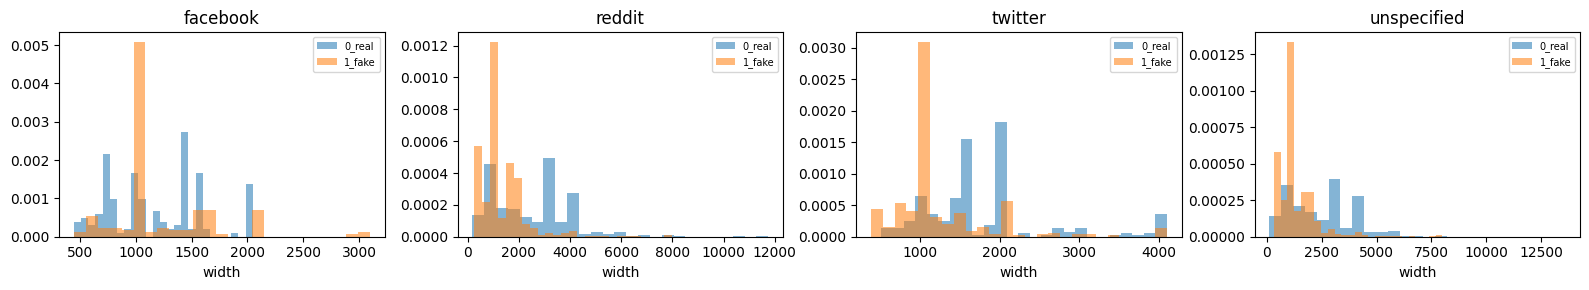

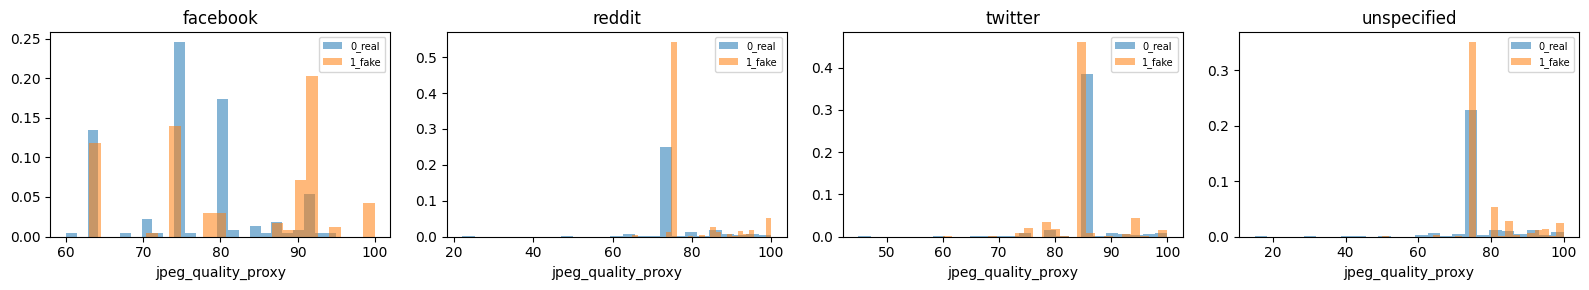

Saved four metadata figures to /content/results/figures


In [ ]:
numeric = ['width','height','aspect_ratio','file_bytes','bytes_per_pixel','jpeg_quality_proxy']
grouped = valid.groupby(['platform','label'], dropna=False)
stats = grouped[numeric].agg(['count','median','mean','std']).round(3)
print(stats.to_string())
fmt = valid.groupby(['platform','label','actual_format']).size().rename('n').reset_index()
exif = grouped.exif_present.agg(['sum','count','mean']).round(4)
print('Actual format counts:'); print(fmt.to_string(index=False))
print('EXIF presence:'); print(exif.to_string())
report('metadata_distributions', {'numeric_by_platform_label': json.loads(stats.reset_index().to_json(orient='records')),
  'formats_by_platform_label': fmt.to_dict('records'),
  'exif_by_platform_label': exif.reset_index().to_dict('records'),
  'jpeg_quality_note': 'Approximate IJG luminance-table fit; not definitive original JPEG quality.'})

for col in ('file_bytes','bytes_per_pixel','width','jpeg_quality_proxy'):
    fig, axes = plt.subplots(1, len(valid.platform.unique()), figsize=(4*len(valid.platform.unique()), 3), squeeze=False)
    for ax, platform in zip(axes[0], sorted(valid.platform.unique())):
        for label, group in valid[valid.platform==platform].groupby('label'):
            values = group[col].dropna().astype(float)
            if len(values): ax.hist(values, bins=25, alpha=.55, density=True, label=label)
        ax.set_title(platform); ax.set_xlabel(col); ax.legend(fontsize=7)
    fig.tight_layout(); fig.savefig(FIGURES / f'metadata_{col}.png', dpi=110); plt.show(); plt.close(fig)
print('Saved four metadata figures to', FIGURES)

## 5. Class balance and split sanity

Counts are evaluated before any model. Here, `test/reddit` is a distinct folder from `train` and `val`; the cross-platform shortcut diagnostic below uses its Reddit images as source training data only to ensure platform is known. This is **not** a benchmark result or the authors' precise training protocol. Cross-split duplicate checks follow.

In [ ]:
balance = valid.groupby(['split','platform','label']).size().unstack(fill_value=0)
balance['total'] = balance.sum(axis=1)
balance['fake_fraction'] = (balance.get('1_fake',0) / balance['total']).round(4)
print(balance.to_string())
issues = []
if not len(valid): issues.append('No readable labeled images')
if missing: issues.append('Missing expected folders')
if int((~df.readable).sum()): issues.append('Unreadable files present')
if any(balance['total']==0): issues.append('Empty group')
report('balance_split_sanity', {'table': balance.reset_index().to_dict('records'), 'issues': issues,
  'train_val_platform_provenance': 'not encoded in path', 'cross_platform_source': 'test/reddit only'})

label              0_real  1_fake  total  fake_fraction
split platform                                         
test  facebook        160     160    320         0.5000
      reddit          750     750   1500         0.5000
      twitter         341     342    683         0.5007
train unspecified    1356    1356   2712         0.5000
val   unspecified     199     199    398         0.5000
{
  "balance_split_sanity": {
    "table": [
      {
        "split": "test",
        "platform": "facebook",
        "0_real": 160,
        "1_fake": 160,
        "total": 320,
        "fake_fraction": 0.5
      },
      {
        "split": "test",
        "platform": "reddit",
        "0_real": 750,
        "1_fake": 750,
        "total": 1500,
        "fake_fraction": 0.5
      },
      {
        "split": "test",
        "platform": "twitter",
        "0_real": 341,
        "1_fake": 342,
        "total": 683,
        "fake_fraction": 0.5007
      },
      {
        "split": "train",
        "platfo

## 6. Metadata-only shortcut diagnostic

Logistic regression and small histogram gradient boosting use **metadata only**, with format encoded as a category. We report accuracy, ROC AUC, class prevalence, majority-class baseline, and the confusion matrix. The random 70/30 stratified split estimates how easily metadata predicts a label within this corpus; it may contain duplicate leakage. The cross-platform split trains on `test/reddit` and tests on `test/twitter`+`test/facebook`, using those folders solely for this diagnostic. Neither result measures visual deepfake detection. A flag means AUC ≥ 0.60 and at least 0.05 above accuracy baseline; this is a screening heuristic, not a significance test.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

features = numeric + ['exif_present','actual_format']
model_df = valid.copy()
model_df['exif_present'] = model_df.exif_present.astype(int)
model_df['y'] = (model_df.label=='1_fake').astype(int)
prep = ColumnTransformer([
 ('num', Pipeline([('impute',SimpleImputer(strategy='median', add_indicator=True)),
                   ('scale',StandardScaler())]), numeric+['exif_present']),
 ('fmt', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['actual_format'])])
models = {
 'logistic_regression': LogisticRegression(max_iter=1000, random_state=SEED),
 'hist_gradient_boosting': HistGradientBoostingClassifier(max_iter=70, max_leaf_nodes=7,
                                                          min_samples_leaf=20, random_state=SEED)}

def evaluate(name, train, test):
    out = {}
    if len(train)<20 or len(test)<10 or train.y.nunique()<2 or test.y.nunique()<2:
        return {'status': 'insufficient rows or both labels not present',
                'train_n': len(train), 'test_n': len(test)}
    baseline = float(max(test.y.mean(), 1-test.y.mean()))
    for model_name, estimator in models.items():
        pipe = Pipeline([('prep', prep), ('model', estimator)])
        pipe.fit(train[features], train.y)
        prob = pipe.predict_proba(test[features])[:,1]
        pred = (prob>=0.5).astype(int)
        acc = float(accuracy_score(test.y,pred)); auc = float(roc_auc_score(test.y,prob))
        out[model_name] = {'train_n': len(train), 'test_n': len(test),
            'test_fake_fraction': float(test.y.mean()), 'majority_accuracy': baseline,
            'accuracy': acc, 'roc_auc': auc,
            'confusion_matrix_rows_real_fake': confusion_matrix(test.y,pred,labels=[0,1]).tolist(),
            'real_false_positive_rate': float(((test.y==0)&(pred==1)).sum()/(test.y==0).sum()),
            'shortcut_flag_heuristic': bool(auc>=.60 and acc>=baseline+.05)}
    return out

if len(model_df)>=30 and model_df.y.nunique()==2:
    tr, te = train_test_split(model_df, test_size=.30, stratify=model_df.y, random_state=SEED)
    random_result = evaluate('random',tr,te)
else: random_result = {'status':'insufficient labeled images'}
reddit = model_df[(model_df.split=='test')&(model_df.platform=='reddit')]
other = model_df[(model_df.split=='test')&(model_df.platform.isin(['twitter','facebook']))]
cross_result = evaluate('reddit_to_twitter_facebook', reddit, other)
report('metadata_shortcuts', {'random_split': random_result,
  'reddit_to_twitter_facebook': cross_result,
  'reddit_to_twitter': evaluate('reddit_to_twitter',reddit,other[other.platform=='twitter']),
  'reddit_to_facebook': evaluate('reddit_to_facebook',reddit,other[other.platform=='facebook']),
  'interpretation': 'Diagnostic metadata association only; random split may leak duplicates.'})

{
  "metadata_shortcuts": {
    "random_split": {
      "logistic_regression": {
        "train_n": 3929,
        "test_n": 1684,
        "test_fake_fraction": 0.5,
        "majority_accuracy": 0.5,
        "accuracy": 0.7773159144893111,
        "roc_auc": 0.8674290937198504,
        "confusion_matrix_rows_real_fake": [
          [
            709,
            133
          ],
          [
            242,
            600
          ]
        ],
        "real_false_positive_rate": 0.15795724465558195,
        "shortcut_flag_heuristic": true
      },
      "hist_gradient_boosting": {
        "train_n": 3929,
        "test_n": 1684,
        "test_fake_fraction": 0.5,
        "majority_accuracy": 0.5,
        "accuracy": 0.8889548693586699,
        "roc_auc": 0.9595353219627513,
        "confusion_matrix_rows_real_fake": [
          [
            774,
            68
          ],
          [
            119,
            723
          ]
        ],
        "real_false_positive_rate": 0.080760

## 7. Exact and near duplicates

MD5 is used only as a byte-identity grouping key. Perceptual hash (64-bit pHash; Hamming distance ≤ `NEAR_HASH_DISTANCE`) is a **candidate** near-duplicate check. Perceptual collisions and visually related but distinct images require manual review. Counts include within and across split/platform/label, with train–test leakage shown separately. Hashes cover all readable labeled images; an indexed BK tree avoids a full quadratic scan. Pair details are saved as CSV without image content.

In [ ]:
hash_rows=[]
for row in tqdm(valid.itertuples(index=False), total=len(valid), desc='Hashing'):
    path = Path(row.path)
    try:
        md5 = hashlib.md5(path.read_bytes()).hexdigest()
        with Image.open(path) as im: phash = int(str(imagehash.phash(ImageOps.exif_transpose(im))),16)
        hash_rows.append({'relative_path':row.relative_path,'split':row.split,'platform':row.platform,
                          'label':row.label,'md5':md5,'phash':phash})
    except Exception as exc:
        print('Hash error:', row.relative_path, type(exc).__name__)
h = pd.DataFrame(hash_rows)
exact_pairs=[]
for _, group in h.groupby('md5'):
    indices = group.index.tolist()
    for pos, i in enumerate(indices):
        for j in indices[pos+1:]: exact_pairs.append((i,j,0,'exact'))

class BKNode:
    def __init__(self, value, idx): self.value=value; self.indices=[idx]; self.children={}
    def add(self, value, idx):
        dist=(self.value^value).bit_count()
        if dist==0: self.indices.append(idx)
        elif dist in self.children: self.children[dist].add(value,idx)
        else: self.children[dist]=BKNode(value,idx)
    def query(self, value, radius, found):
        dist=(self.value^value).bit_count()
        if dist<=radius: found.extend((idx,dist) for idx in self.indices)
        for edge, child in self.children.items():
            if dist-radius<=edge<=dist+radius: child.query(value,radius,found)

tree=None; near_pairs=[]
for i, row in tqdm(enumerate(h.itertuples(index=False)), total=len(h), desc='Near-duplicate index'):
    value=int(row.phash); matches=[]
    if tree is not None:
        tree.query(value,NEAR_HASH_DISTANCE,matches)
        near_pairs.extend((j,i,d,'near') for j,d in matches if h.iloc[j].md5!=row.md5)
        tree.add(value,i)
    else: tree=BKNode(value,i)

def describe_pairs(pairs):
    records=[]
    for i,j,d,kind in pairs:
        a,b=h.iloc[i],h.iloc[j]
        records.append({'kind':kind,'path_a':a.relative_path,'path_b':b.relative_path,
          'hash_distance':d,'split_a':a.split,'split_b':b.split,
          'platform_a':a.platform,'platform_b':b.platform,'label_a':a.label,'label_b':b.label,
          'across_splits':a.split!=b.split,'across_platforms':a.platform!=b.platform,
          'across_labels':a.label!=b.label,
          'train_test_leakage':{a.split,b.split}=={'train','test'}})
    return pd.DataFrame(records)
pair_df=describe_pairs(exact_pairs+near_pairs)
pair_df.to_csv(RESULTS/'duplicate_pairs.csv',index=False)
def pair_summary(frame):
    if frame.empty: return {'pairs':0,'within_splits':0,'within_platforms':0,
      'within_labels':0,'across_splits':0,'across_platforms':0,
      'across_labels':0,'train_test_leakage':0}
    return {'pairs':len(frame), 'within_splits':int((~frame.across_splits).sum()),
      'within_platforms':int((~frame.across_platforms).sum()),
      'within_labels':int((~frame.across_labels).sum()),
      **{key:int(frame[key].sum()) for key in
            ('across_splits','across_platforms','across_labels','train_test_leakage')}}
exact_summary=pair_summary(pair_df[pair_df.kind=='exact'] if not pair_df.empty else pair_df)
near_summary=pair_summary(pair_df[pair_df.kind=='near'] if not pair_df.empty else pair_df)
report('duplicates', {'hashed_images':len(h),'exact':exact_summary,'near_phash':near_summary,
  'near_distance_threshold':NEAR_HASH_DISTANCE,
  'note':'Pairs are candidate relationships; near duplicates need visual review.'})

Hashing:   0%|          | 0/5613 [00:00<?, ?it/s]

Near-duplicate index:   0%|          | 0/5613 [00:00<?, ?it/s]

{
  "duplicates": {
    "hashed_images": 5613,
    "exact": {
      "pairs": 445,
      "within_splits": 77,
      "within_platforms": 148,
      "within_labels": 445,
      "across_splits": 368,
      "across_platforms": 297,
      "across_labels": 0,
      "train_test_leakage": 260
    },
    "near_phash": {
      "pairs": 5,
      "within_splits": 2,
      "within_platforms": 2,
      "within_labels": 5,
      "across_splits": 3,
      "across_platforms": 3,
      "across_labels": 0,
      "train_test_leakage": 3
    },
    "near_distance_threshold": 5,
    "note": "Pairs are candidate relationships; near duplicates need visual review."
  }
}


## 8. Face applicability for FR-8

Try CPU MTCNN. If unavailable because of Colab torch/torchvision incompatibility, fall back to OpenCV's bundled Haar cascade, recording which detector ran. Haar results are less reliable and are **not directly comparable** with MTCNN. Sampling is fixed-seed and per split × platform × label; percentages apply to the sample, not necessarily the full dataset. Small faces are counted when any detected box is <50×50 px. Face boxes are not saved, and no crops are shared.

In [ ]:
detector_name='MTCNN'; detector_error=None
try:
    from facenet_pytorch import MTCNN
    mtcnn=MTCNN(keep_all=True, device='cpu', post_process=False)
    def detect_faces(im):
        scale=min(1.0, 800/max(im.size))
        small=im.resize((round(im.width*scale),round(im.height*scale))) if scale<1 else im
        boxes, _ = mtcnn.detect(small)
        return [] if boxes is None else [tuple(float(v)/scale for v in b) for b in boxes]
except Exception as exc:
    detector_error=f'{type(exc).__name__}: {exc}'
    import cv2
    detector_name='OpenCV Haar fallback'
    cascade=cv2.CascadeClassifier(cv2.data.haarcascades+'haarcascade_frontalface_default.xml')
    if cascade.empty(): raise RuntimeError('Neither MTCNN nor OpenCV Haar face detector is available')
    def detect_faces(im):
        scale=min(1.0, 800/max(im.size))
        small=im.resize((round(im.width*scale),round(im.height*scale))) if scale<1 else im
        rgb=np.asarray(small.convert('RGB'))
        gray=cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY)
        boxes=cascade.detectMultiScale(gray,scaleFactor=1.1,minNeighbors=4,minSize=(20,20))
        return [(float(x)/scale,float(y)/scale,float(x+w)/scale,float(y+h)/scale) for x,y,w,h in boxes]

sample_parts=[]
for _, group in valid.groupby(['split','platform','label']):
    n=len(group) if SAMPLE_PER_GROUP is None else min(len(group),SAMPLE_PER_GROUP)
    sample_parts.append(group.sample(n=n,random_state=SEED))
face_sample=pd.concat(sample_parts,ignore_index=True) if sample_parts else valid.iloc[:0]
face_rows=[]
for row in tqdm(face_sample.itertuples(index=False),total=len(face_sample),desc='CPU face detection'):
    try:
        with Image.open(row.path) as im:
            im=ImageOps.exif_transpose(im).convert('RGB')
            boxes=detect_faces(im)
        dims=[(max(0,x2-x1),max(0,y2-y1)) for x1,y1,x2,y2 in boxes]
        face_rows.append({'relative_path':row.relative_path,'split':row.split,
          'platform':row.platform,'label':row.label,'face_count':len(dims),
          'small_face_count':sum(w<50 or h<50 for w,h in dims),
          'face_widths':json.dumps([round(w,1) for w,_ in dims]),
          'face_heights':json.dumps([round(h,1) for _,h in dims]),'error':''})
    except Exception as exc:
        face_rows.append({'relative_path':row.relative_path,'split':row.split,
          'platform':row.platform,'label':row.label,'face_count':np.nan,
          'small_face_count':np.nan,'face_widths':'[]','face_heights':'[]',
          'error':f'{type(exc).__name__}: {str(exc)[:120]}'})
faces=pd.DataFrame(face_rows); faces.to_csv(RESULTS/'face_sample.csv',index=False)
good_faces=faces[faces.error==''].copy()
face_group=good_faces.groupby(['platform','label']).agg(
  sampled=('face_count','size'),with_face=('face_count',lambda s:int((s>=1).sum())),
  small_face_images=('small_face_count',lambda s:int((s>=1).sum())))
face_group['face_fraction']=(face_group.with_face/face_group.sampled).round(4)
print(face_group.to_string())
all_widths=[w for vals in good_faces.face_widths for w in json.loads(vals)]
all_heights=[w for vals in good_faces.face_heights for w in json.loads(vals)]
face_sizes={'detected_faces':len(all_widths), 'width_median_px':float(np.median(all_widths)) if all_widths else None,
  'height_median_px':float(np.median(all_heights)) if all_heights else None,
  'faces_under_50x50':sum(w<50 or h<50 for w,h in zip(all_widths,all_heights))}
report('face_applicability', {'detector':detector_name,'mtcnn_error':detector_error,
  'sampled_images':len(faces),'detection_errors':int((faces.error!='').sum()),
  'groups':face_group.reset_index().to_dict('records'),'face_sizes':face_sizes})

CPU face detection:   0%|          | 0/400 [00:00<?, ?it/s]

                    sampled  with_face  small_face_images  face_fraction
platform    label                                                       
facebook    0_real       40         17                  4         0.4250
            1_fake       40         26                  4         0.6500
reddit      0_real       40         11                  1         0.2750
            1_fake       40         22                  4         0.5500
twitter     0_real       40         22                  5         0.5500
            1_fake       40         23                  4         0.5750
unspecified 0_real       80         23                  3         0.2875
            1_fake       80         45                  8         0.5625
{
  "face_applicability": {
    "detector": "MTCNN",
    "mtcnn_error": null,
    "sampled_images": 400,
    "detection_errors": 0,
    "groups": [
      {
        "platform": "facebook",
        "label": "0_real",
        "sampled": 40,
        "with_face": 17,
       

## 9. Contact sheets

Sample up to 30 images per **known** platform × label across the dataset. Unspecified train/val provenance receives a separate group. Downscale to small thumbnails and save PNG grids under `figures/`. Contact sheets contain copyrighted or identifiable images: keep `results.zip` private.

In [ ]:
from PIL import ImageDraw
contact_counts=[]
for (platform,label), group in valid.groupby(['platform','label']):
    chosen=group.sample(n=min(CONTACT_PER_LABEL_PLATFORM,len(group)),random_state=SEED)
    cols=6; rows_n=math.ceil(len(chosen)/cols)
    sheet=Image.new('RGB',(cols*128,rows_n*112),'white'); draw=ImageDraw.Draw(sheet)
    rendered=0
    for k, row in enumerate(chosen.itertuples(index=False)):
        try:
            with Image.open(row.path) as im:
                thumb=ImageOps.exif_transpose(im).convert('RGB')
                thumb.thumbnail((120,88))
                x=(k%cols)*128+(128-thumb.width)//2; y=(k//cols)*112
                sheet.paste(thumb,(x,y)); draw.text(((k%cols)*128+4,y+90),str(k+1),fill='black')
                rendered+=1
        except Exception as exc: print('Contact image failed:', row.relative_path, type(exc).__name__)
    output=FIGURES/f'contact_{platform}_{label}.png'
    sheet.save(output,optimize=True)
    contact_counts.append({'platform':platform,'label':label,'selected':len(chosen),
                           'rendered':rendered,'file':str(output)})
report('contact_sheets', {'groups':contact_counts})

{
  "contact_sheets": {
    "groups": [
      {
        "platform": "facebook",
        "label": "0_real",
        "selected": 30,
        "rendered": 30,
        "file": "/content/results/figures/contact_facebook_0_real.png"
      },
      {
        "platform": "facebook",
        "label": "1_fake",
        "selected": 30,
        "rendered": 30,
        "file": "/content/results/figures/contact_facebook_1_fake.png"
      },
      {
        "platform": "reddit",
        "label": "0_real",
        "selected": 30,
        "rendered": 30,
        "file": "/content/results/figures/contact_reddit_0_real.png"
      },
      {
        "platform": "reddit",
        "label": "1_fake",
        "selected": 30,
        "rendered": 30,
        "file": "/content/results/figures/contact_reddit_1_fake.png"
      },
      {
        "platform": "twitter",
        "label": "0_real",
        "selected": 30,
        "rendered": 30,
        "file": "/content/results/figures/contact_twitter_0_real.png"
    

## 10. Final package and interpretation guide

Every recorded headline number is printed by `report()` and written to `summary.json`; detail files and figures are in `/content/results/`. This EDA cannot prove image authenticity, consent, legal rights, model performance, or video/audio suitability. Compare the shortcut and duplicate findings before choosing WildRF for training. In particular, inspect false positives on real images and compressed formats in a later model evaluation. Download the package and save the executed notebook with outputs.

In [ ]:
report('status', {'stage':'complete','dataset_downloaded':True,
  'output_files':sorted(str(p.relative_to(RESULTS)) for p in RESULTS.rglob('*') if p.is_file())})
archive=Path('/content/results.zip')
if archive.exists(): archive.unlink()
shutil.make_archive('/content/results','zip',root_dir=RESULTS)
print('RESULTS ZIP:',archive,'bytes:',archive.stat().st_size)
from google.colab import files
files.download(str(archive))

{
  "status": {
    "stage": "complete",
    "dataset_downloaded": true,
    "output_files": [
      "duplicate_pairs.csv",
      "face_sample.csv",
      "figures/contact_facebook_0_real.png",
      "figures/contact_facebook_1_fake.png",
      "figures/contact_reddit_0_real.png",
      "figures/contact_reddit_1_fake.png",
      "figures/contact_twitter_0_real.png",
      "figures/contact_twitter_1_fake.png",
      "figures/contact_unspecified_0_real.png",
      "figures/contact_unspecified_1_fake.png",
      "figures/metadata_bytes_per_pixel.png",
      "figures/metadata_file_bytes.png",
      "figures/metadata_jpeg_quality_proxy.png",
      "figures/metadata_width.png",
      "metadata.csv",
      "summary.json"
    ]
  }
}
RESULTS ZIP: /content/results.zip bytes: 3959501


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>